In [1]:
import numpy as np
import os

from kuramoto.solvers import solve_kuramoto

# Define the path to your generated data
# We use '../' to move up from the notebooks folder to the project root
data_path = "../data/examples/small_demo.npz"

# Load the dataset
if os.path.exists(data_path):
    dataset = np.load(data_path)

    # List the available arrays in the file
    print(f"Keys available in dataset: {list(dataset.keys())}")

    # Access specific data (e.g., phase trajectories)
    phases = dataset['theta']
    times = dataset['time']

    print(f"Phases shape: {phases.shape} (Timesteps, Oscillators)")
    print(f"Time vector length: {len(times)}")
else:
    print(f"Dataset not found at {data_path}. Please run the generation script first!")

# Example: Accessing natural frequencies
if 'omega' in dataset:
    omega = dataset['omega']
    print(f"First 5 natural frequencies: {omega[:5]}")


Keys available in dataset: ['omega', 'theta', 'dtheta', 'time', 'initial_conditions', 'coupling', 'adjacency', 'network_stats', 'noise_std', 'freq_pdf', 'phase_pdf']
Phases shape: (1000, 50) (Timesteps, Oscillators)
Time vector length: 1000
First 5 natural frequencies: [ 1.25444825  0.77690202  0.96488113 -1.08217839  0.86701736]


In [2]:
from kuramoto.topologies import load_topology, compute_chromatic_polynomial

# Load a canonical topology
G = load_topology("tree_of_life", return_graph=True)

# Compute the chromatic polynomial
poly = compute_chromatic_polynomial(G)
print(f"Chromatic Polynomial: {poly}")

Chromatic Polynomial: k**10 - 22*k**9 + 215*k**8 - 1224*k**7 + 4468*k**6 - 10826*k**5 + 17369*k**4 - 17730*k**3 + 10395*k**2 - 2646*k


In [3]:
import numpy as np
from kuramoto.api import generate_kuramoto_dataset

N = 100
rng = np.random.default_rng(seed=27)
omega = rng.normal(0.0, 1.0, size=N)

dataset = generate_kuramoto_dataset(
    n_oscillators=N,
    natural_frequencies=omega,
    coupling=1.0,
    timesteps=1000,
    dt=0.05,
    topology="small_world",
    topology_kwargs={"k": 4, "p": 0.2},
    seed=27,
)

times = dataset["time"]
phases = dataset["theta"]

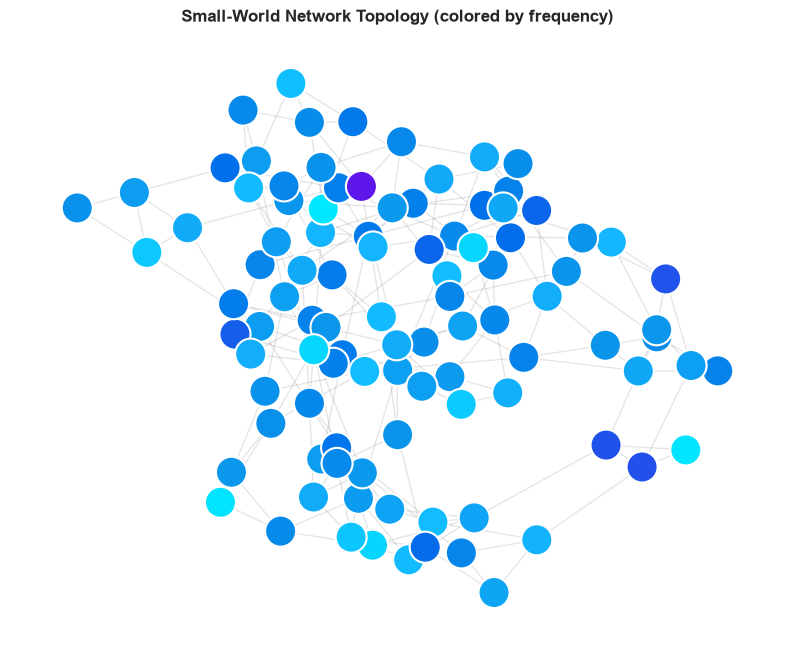

In [4]:
from kuramoto.analysis.viz import plot_network

# 1. Visualize the oscillator network structure (small-world topology)
plot_network(
    adjacency=dataset["adjacency"],
    node_values=dataset["omega"],
    cmap_name="gradient_4",
    title="Small-World Network Topology (colored by frequency)"
)

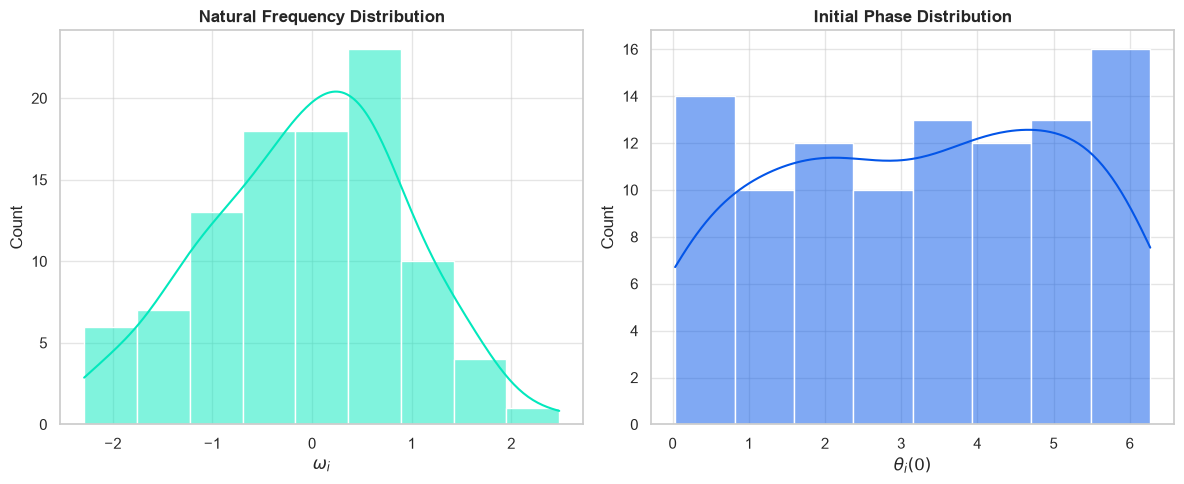

In [5]:
from kuramoto.analysis.viz import plot_distributions

# 2. Visualize natural frequency and initial phase distributions
plot_distributions(
    omega=dataset["omega"],
    theta_0=dataset["initial_conditions"],
    cmap_name="gradient_3"
)